# MNIST-Planted-Cov: the dataset, nothing else

Just generates and looks at the dataset produced by `configs/data/mnist_planted_cov.yaml`
with this run's overrides -- no model, no training:

    experiment:                   planted_parents
    kappa:                        0.9
    num_covariates:               5
    corruption:                   gaussian
    corruption_strength:          0.4   (channel 5 / X only)
    concept_corruption_strength:  0.0   (channels 1-4, clean)

`features` is a `[num_covariates, 28, 28]` tensor, one MNIST digit image per channel.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset import (
    get_MNIST_add_cov_datasets,
    get_mnist_add_cov_concept_names,
    get_mnist_add_cov_oracle_names,
    summarize_dataset,
)

config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_planted_cov.yaml"),
)
config_data.data_path = "datasets/"   # local path; the cluster uses work/Data/

# This run's overrides
config_data.experiment = "planted_parents"
config_data.kappa = 0.9
config_data.num_covariates = 5
config_data.corruption = "gaussian"
config_data.corruption_strength = 0.4
config_data.concept_corruption_strength = 0.0

print(OmegaConf.to_yaml(config_data))

data_path: datasets/
incomplete_dir: incomplete_data/
defaults:
- data_defaults
dataset: MNIST-Add-Cov
experiment: planted_parents
kappa: 0.9
planted_function: ${data.experiment}
num_classes: 8
num_concepts: 4
num_residuals: 1
num_covariates: 5
train_dataset_size: 12000
val_dataset_size: 2400
test_dataset_size: 10000
val_percent: 0.2
data_seed: null
save_data: false
save_data_name: null
data_dir_name: null
removed_concepts: []
corruption: gaussian
corruption_strength: 0.4
concept_corruption: null
concept_corruption_strength: 0.0
test_corruption_strength: null
test_concept_corruption_strength: null
save_predicted_concepts_residuals: true
save_residual_channel: true
save_concept_and_residual_channel: true



## Generate

In [2]:
trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=0)
concept_names = get_mnist_add_cov_concept_names(config_data.experiment)
oracle_names = get_mnist_add_cov_oracle_names(config_data.experiment)
print(len(trainset), len(valset), len(testset))
print(concept_names, "| oracle:", oracle_names)

MNIST-Planted-Cov split fingerprints (data seed=0, experiment=planted_parents, kappa=0.9):
  train n=12000  sha256[:16]=eedaa597d011581c
  val   n=2400   sha256[:16]=14a8c98eee93cac7
  test  n=10000  sha256[:16]=fc1c8bcb6536c527
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  planted parents : ['A', 'B']
  Matching fingerprints => identical train/val/test samples across machines.
12000 2400 10000
['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5'] | oracle: ['A2::unused', 'X::digit5_ge_5']


## Summary

Marginal concept-X correlations, the concept-only task ceiling the residual has to beat,
and whether X is determined by (A, B) -- the sanity check baked into the dataset script
itself (`summarize_dataset`).

In [3]:
summarize_dataset(trainset)

N=12000   experiment=planted_parents   kappa=0.9
  X depends on A and B, both positively
Channels: 5 (5 used, 0 padding)
Concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
Concept means ['A', 'B', 'D1', 'D2']: [0.5 0.5 0.5 0.5]
P(X = 1) = 0.5057   (0.5 by construction, any kappa)
Task class counts: [2839  161 1463 1537 1505 1495  125 2875]

Marginal concept-X correlations (what the cross-block should recover):
  Corr(A, X) = +0.4454   expected +0.4500  <- parent
  Corr(B, X) = +0.4594   expected +0.4500  <- parent
  Corr(D1, X) = +0.0140   expected +0.0000  (null channel)
  Corr(D2, X) = +0.0077   expected +0.0000  (null channel)

Is X determined by the exposed concepts?
  A=0, B=0: n=3000   P(X=1)=0.0537
  A=0, B=1: n=3000   P(X=1)=0.5123
  A=1, B=0: n=3000   P(X=1)=0.4983
  A=1, B=1: n=3000   P(X=1)=0.9583

Concept-only task ceiling : 0.7297   (expected 0.7250)
Residual headroom         : 0.2703
The residual-only probe of X must clear the cei

## One sample

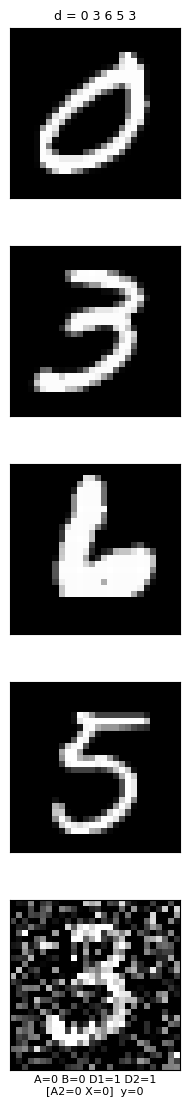

In [4]:
def show_sample(dataset, index, axes=None):
    """Plot every digit channel of one sample, titled with its digits and labels."""
    item = dataset[index]
    features = item["features"]                       # [num_covariates, 28, 28]
    concepts = item["concepts"].tolist()
    hidden = item["hidden_concepts"].tolist()
    digits = item["digit_labels"].tolist()
    short_names = [n.split("::")[0] for n in concept_names]
    short_oracle = [n.split("::")[0] for n in oracle_names]

    n_ch = features.shape[0]
    if axes is None:
        _, axes = plt.subplots(n_ch, 1, figsize=(2.0, 2.3 * n_ch))
    for channel, ax in enumerate(axes):
        ax.imshow(features[channel], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].set_title("d = " + " ".join(str(d) for d in digits), fontsize=9)
    axes[-1].set_xlabel(
        " ".join(f"{n}={v:.0f}" for n, v in zip(short_names, concepts))
        + "\n[" + " ".join(f"{n}={v:.0f}" for n, v in zip(short_oracle, hidden))
        + f"]  y={int(item['labels'])}",
        fontsize=8,
    )
    return axes


show_sample(trainset, 0)
plt.tight_layout()
plt.show()

## A grid of samples

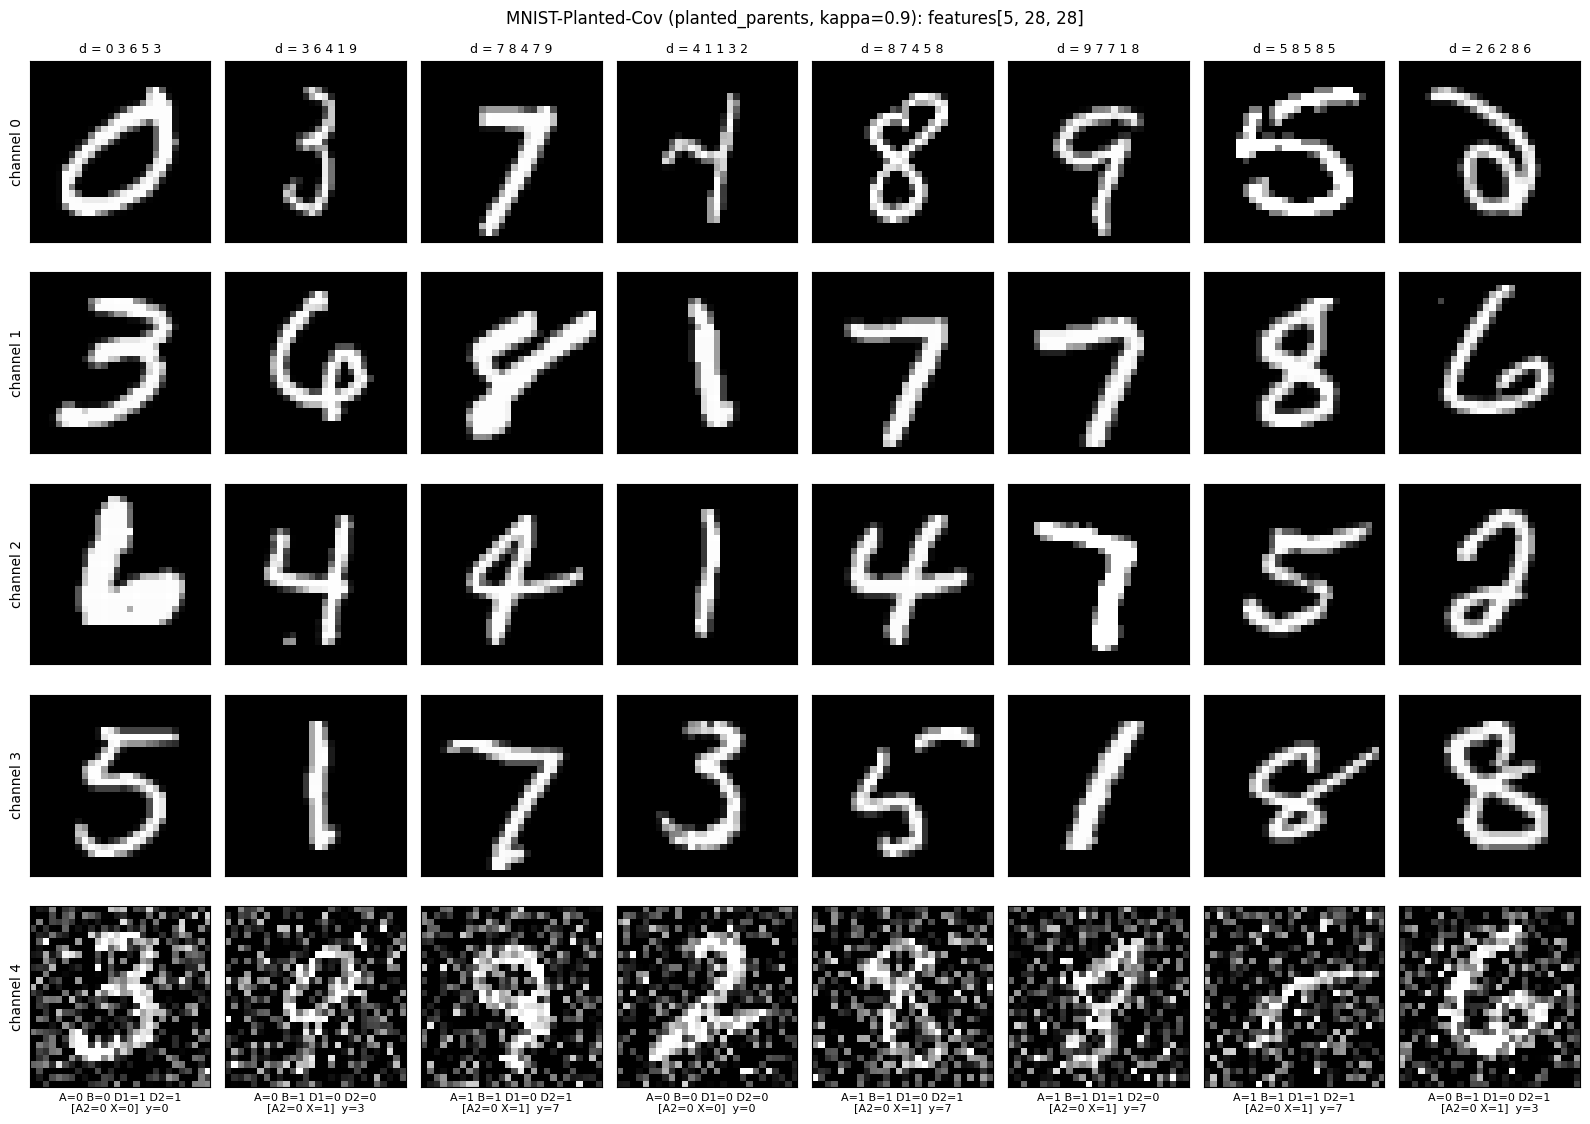

In [5]:
def show_samples(dataset, indices, suptitle=""):
    indices = list(indices)
    n_ch = dataset[indices[0]]["features"].shape[0]
    fig, axes = plt.subplots(n_ch, len(indices), figsize=(2.0 * len(indices), 2.3 * n_ch))
    for column, index in enumerate(indices):
        show_sample(dataset, index, axes=axes[:, column])
    for ch in range(n_ch):
        axes[ch, 0].set_ylabel(f"channel {ch}")
    fig.suptitle(
        suptitle or f"MNIST-Planted-Cov ({config_data.experiment}, kappa={config_data.kappa}): "
        f"features[{n_ch}, 28, 28]"
    )
    fig.tight_layout()
    return fig


show_samples(trainset, range(8))
plt.show()

## Class / concept balance

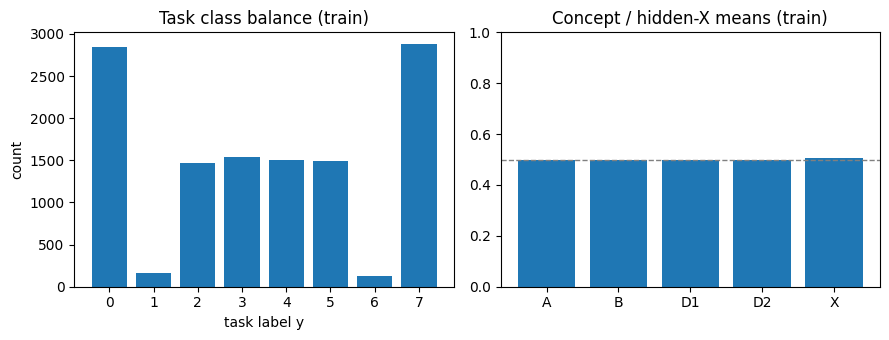

In [6]:
task_labels = trainset.task_labels
concept_means = trainset.observed_concepts.mean(0)
x_mean = trainset.hidden_concepts[:, 1].mean()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(range(trainset.num_classes), np.bincount(task_labels, minlength=trainset.num_classes))
axes[0].set_xlabel("task label y")
axes[0].set_ylabel("count")
axes[0].set_title("Task class balance (train)")

names = [n.split("::")[0] for n in trainset.observed_concept_names] + ["X"]
means = list(concept_means) + [x_mean]
axes[1].bar(names, means)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1)
axes[1].set_title("Concept / hidden-X means (train)")

fig.tight_layout()
plt.show()

## Probe

In [7]:
from pathlib import Path
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "planted_planted_parents_planted_parents_kappa09_corr04_"
    "L_int_extension_loss_weight_1_2026-09-08_17-50-00_b226c"
)
SPLIT, dataset = "test", testset          # from get_MNIST_planted_cov_datasets

n_concepts = len(dataset.kept_concept_idx)
mu = torch.load(RUN / SPLIT / "c_res_mu.pt").numpy()      # [N, C+R] Gaussian means
c_mu, res_mu = mu[:, :n_concepts], mu[:, n_concepts:]

X = (np.asarray(dataset.hidden_concepts)[:, 1] > 0.5).astype(int)
obs = np.asarray(dataset.observed_concepts)
short = [n.split("::")[0] for n in dataset.observed_concept_names]

# Alignment: y is a deterministic function of the sample, so identical y over
# the whole split means identical samples in identical order.
y_saved = torch.load(RUN / SPLIT / "y_true.pt").numpy().ravel()
assert np.array_equal(y_saved, np.asarray(dataset.task_labels)), "split mismatch"

# --- 1. leakage: how much of the residual is just a function of the concepts?
design = np.c_[np.ones(len(c_mu)), c_mu]
beta, *_ = np.linalg.lstsq(design, res_mu, rcond=None)
r_clean = res_mu - design @ beta
leakage = 1 - r_clean.var(0) / res_mu.var(0)
print(f"leakage R^2 of res_mu on concept means : {np.round(leakage, 3)}   (want < 0.5)")

# Which concept, if any, the residual is tracking.
print(f"\n{'target':<8}{'AUROC(res_mu)':>15}{'AUROC(cleaned)':>16}")
for name, t in [("X", X)] + [(n, obs[:, j] > 0.5) for j, n in enumerate(short)]:
    print(f"{name:<8}{roc_auc_score(t, res_mu[:, 0]):>15.3f}"
          f"{roc_auc_score(t, r_clean[:, 0]):>16.3f}")

# --- 2. the gate: is X linearly decodable from the residual alone?
ceiling = dataset.concept_only_ceiling()
print(f"\n{'probe input':<24}{'CV accuracy for X':>20}")
for name, mat in (("concepts only", c_mu),
                  ("residual only", res_mu),
                  ("concepts + residual", mu)):
    acc = cross_val_score(LogisticRegression(max_iter=2000), mat, X, cv=5).mean()
    print(f"  {name:<22}{acc:>20.3f}")
print(f"  {'concept-only ceiling':<22}{ceiling:>20.3f}")
print(f"\nGate: residual-only must clear {ceiling:.3f}, and stay under ~0.90")
print("(above 0.90 the residual reads X straight off d5 and Sigma has nothing to encode)")

leakage R^2 of res_mu on concept means : [0.995]   (want < 0.5)

target    AUROC(res_mu)  AUROC(cleaned)
X                 0.367           0.493
A                 0.043           0.484
B                 0.661           0.511
D1                0.499           0.495
D2                0.529           0.514

probe input                CV accuracy for X
  concepts only                        0.734
  residual only                        0.646
  concepts + residual                  0.732
  concept-only ceiling                 0.729

Gate: residual-only must clear 0.729, and stay under ~0.90
(above 0.90 the residual reads X straight off d5 and Sigma has nothing to encode)


## Raw-pixel ceiling for X

Independent of the trained model: how much of X is recoverable straight off the
corrupted d5 image (channel 5, `corruption_strength=0.4`)? This bounds what any
residual-only probe above could possibly achieve -- if this CNN tops out well
under ~0.85, the model's residual-only accuracy isn't the bottleneck, the
corruption is.

In [8]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# trainset / testset already exist from the notebook above.
train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
test_loader  = DataLoader(testset,  batch_size=256, num_workers=0)

net = nn.Sequential(                      # same shape as the SCBM encoder
    nn.Conv2d(1, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, padding="same"), nn.MaxPool2d(2), nn.BatchNorm2d(32), nn.LeakyReLU(),
    nn.Conv2d(32, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(),
    nn.Flatten(), nn.Linear(32 * 3 * 3, 1),
).to(device)

opt = torch.optim.Adam(net.parameters(), lr=1e-3)

for epoch in range(30):
    net.train()
    for b in train_loader:
        x = b["features"][:, 4:5].to(device)          # channel 5 only
        t = b["hidden_concepts"][:, 1].to(device)     # X
        loss = nn.functional.binary_cross_entropy_with_logits(net(x).squeeze(1), t)
        opt.zero_grad(); loss.backward(); opt.step()

    net.eval(); correct = total = 0
    with torch.no_grad():
        for b in test_loader:
            x = b["features"][:, 4:5].to(device)
            t = b["hidden_concepts"][:, 1].to(device)
            correct += ((net(x).squeeze(1) > 0) == (t > 0.5)).sum().item()
            total += len(t)
    print(f"epoch {epoch}  test acc {correct/total:.4f}")

epoch 0  test acc 0.9401


epoch 1  test acc 0.9554


epoch 2  test acc 0.9599


epoch 3  test acc 0.9601


epoch 4  test acc 0.9630


...

epoch 25  test acc 0.9652


epoch 26  test acc 0.9652


epoch 27  test acc 0.9651


epoch 28  test acc 0.9654


epoch 29  test acc 0.9644


## Same check, with the old (pre-`be35b3b`) encoder

`IntCEMMNISTEncoder` used to keep full spatial resolution -- 5 conv layers,
16 channels, **no pooling**, flatten straight to `Linear(16*28*28, ...)` --
before commit `be35b3b` ("mnist working") replaced it with the aggressively
pooled version now active in `models.py` (4 pool stages, 28 -> 14 -> 7 -> 3
-> 1). This cell swaps in that original, higher-resolution architecture as
the probe, to check the ~0.96 ceiling above isn't an artifact of the ad hoc
CNN's particular shape.

Note this is *not* the encoder that trained today's `RUN` checkpoint -- that
was the current, pooled `IntCEMMNISTEncoder`, which collapses every channel
to a single pixel before the linear layer and hasn't been tested as a probe
here. If a probe with *that* architecture underperforms this one, the 1x1
bottleneck is a plausible reason the model's residual-only accuracy (0.646)
falls short of the ceiling.

In [9]:
net_old = nn.Sequential(                  # IntCEMMNISTEncoder as of commit 32c4044, no pooling
    nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Flatten(), nn.Linear(16 * 28 * 28, 1),
).to(device)

opt = torch.optim.Adam(net_old.parameters(), lr=1e-3)

for epoch in range(30):
    net_old.train()
    for b in train_loader:
        x = b["features"][:, 4:5].to(device)          # channel 5 only
        t = b["hidden_concepts"][:, 1].to(device)     # X
        loss = nn.functional.binary_cross_entropy_with_logits(net_old(x).squeeze(1), t)
        opt.zero_grad(); loss.backward(); opt.step()

    net_old.eval(); correct = total = 0
    with torch.no_grad():
        for b in test_loader:
            x = b["features"][:, 4:5].to(device)
            t = b["hidden_concepts"][:, 1].to(device)
            correct += ((net_old(x).squeeze(1) > 0) == (t > 0.5)).sum().item()
            total += len(t)
    print(f"epoch {epoch}  test acc {correct/total:.4f}")

epoch 0  test acc 0.9271


epoch 1  test acc 0.9360


epoch 2  test acc 0.9524


epoch 3  test acc 0.9531


epoch 4  test acc 0.9572


...

epoch 25  test acc 0.9609


epoch 26  test acc 0.9597


epoch 27  test acc 0.9604


epoch 28  test acc 0.9599


epoch 29  test acc 0.9597


## Recoverability at `corruption_strength=1.0`

Same digits, same split (`seed=0`), only channel 5's noise strength changes:
0.4 -> 1.0. At strength 1.0 the added Gaussian noise has the same std as the
image's own dynamic range, so this should push the ceiling well below the
~0.95-0.96 seen above -- the point where `Sigma` would actually have
something non-trivial to encode.

In [10]:
config_data_c1 = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_planted_cov.yaml"),
)
config_data_c1.data_path = "datasets/"
config_data_c1.experiment = "planted_parents"
config_data_c1.kappa = 0.9
config_data_c1.num_covariates = 5
config_data_c1.corruption = "gaussian"
config_data_c1.corruption_strength = 1.0
config_data_c1.concept_corruption_strength = 0.0

trainset_c1, valset_c1, testset_c1 = get_MNIST_add_cov_datasets(config_data_c1, seed=0)
train_loader_c1 = DataLoader(trainset_c1, batch_size=128, shuffle=True, num_workers=0)
test_loader_c1  = DataLoader(testset_c1,  batch_size=256, num_workers=0)


def train_probe(net, train_loader, test_loader, epochs=30):
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    for epoch in range(epochs):
        net.train()
        for b in train_loader:
            x = b["features"][:, 4:5].to(device)          # channel 5 only
            t = b["hidden_concepts"][:, 1].to(device)     # X
            loss = nn.functional.binary_cross_entropy_with_logits(net(x).squeeze(1), t)
            opt.zero_grad(); loss.backward(); opt.step()

        net.eval(); correct = total = 0
        with torch.no_grad():
            for b in test_loader:
                x = b["features"][:, 4:5].to(device)
                t = b["hidden_concepts"][:, 1].to(device)
                correct += ((net(x).squeeze(1) > 0) == (t > 0.5)).sum().item()
                total += len(t)
        acc = correct / total
        print(f"epoch {epoch}  test acc {acc:.4f}")
    return acc

MNIST-Planted-Cov split fingerprints (data seed=0, experiment=planted_parents, kappa=0.9):
  train n=12000  sha256[:16]=b96fe9afa3514ba3
  val   n=2400   sha256[:16]=1b9c63716bc2b5e6
  test  n=10000  sha256[:16]=afcad1552c1d6592
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  planted parents : ['A', 'B']
  Matching fingerprints => identical train/val/test samples across machines.


In [11]:
net_c1 = nn.Sequential(                   # ad hoc CNN, same shape as above
    nn.Conv2d(1, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, padding="same"), nn.MaxPool2d(2), nn.BatchNorm2d(32), nn.LeakyReLU(),
    nn.Conv2d(32, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.LeakyReLU(),
    nn.Flatten(), nn.Linear(32 * 3 * 3, 1),
).to(device)

train_probe(net_c1, train_loader_c1, test_loader_c1)

epoch 0  test acc 0.7767


epoch 1  test acc 0.8049


epoch 2  test acc 0.7937


epoch 3  test acc 0.7965


epoch 4  test acc 0.8068


...

epoch 26  test acc 0.7941


epoch 27  test acc 0.7932


epoch 28  test acc 0.7945


epoch 29  test acc 0.7944


0.7944

In [12]:
net_old_c1 = nn.Sequential(               # old (pre-be35b3b) encoder, no pooling
    nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Conv2d(16, 16, 3, padding=1), nn.BatchNorm2d(16), nn.LeakyReLU(),
    nn.Flatten(), nn.Linear(16 * 28 * 28, 1),
).to(device)

train_probe(net_old_c1, train_loader_c1, test_loader_c1)

epoch 0  test acc 0.7614


epoch 1  test acc 0.7876


epoch 2  test acc 0.7825


epoch 3  test acc 0.7723


epoch 4  test acc 0.7708


...

epoch 26  test acc 0.7690


epoch 27  test acc 0.7717


epoch 28  test acc 0.7710


epoch 29  test acc 0.7723


0.7723